# Matrices 
Using [PANDAS](https://pandas.pydata.org/)

In [2]:
import numpy as np
import pandas as pd


Suppose a local ice cream shop (store 1) keeps track of how many ice cream they sell versus the noon temperature on that day.
Here are registers for 12 days in a roll:

In [3]:
# DATAFRAMES — The primary Pandas data dict-like container structure!

# Creating Pandas DATAFRAME = pd.DataFrame(data, index, columns)
# # # # # # # # # DATAFRAME = pd.DataFrame(d   , i    , c      )

data = {
    'Ice_Cream_Sales': [215,325,185,332,406,522,412,614,544,421,445,408],
    'Temperature_°C': [14.2,16.4,11.9,15.2,18.5,22.1,19.4,25.1,23.4,18.1,22.6,17.2]
}

index = [
    '0°_day', '1°_day','2°_day','3°_day','4°_day',
    '5°_day','6°_day','7°_day','8°_day',
    '9°_day','10°_day','11°_day'
]

columns = ['Ice_Cream_Sales', 'Temperature_°C']

store1 = pd.DataFrame(data, index, columns)

store1 = store1.rename_axis('Days').reset_index()

print(store1)

       Days  Ice_Cream_Sales  Temperature_°C
0    0°_day              215            14.2
1    1°_day              325            16.4
2    2°_day              185            11.9
3    3°_day              332            15.2
4    4°_day              406            18.5
5    5°_day              522            22.1
6    6°_day              412            19.4
7    7°_day              614            25.1
8    8°_day              544            23.4
9    9°_day              421            18.1
10  10°_day              445            22.6
11  11°_day              408            17.2


##  Matrix

Thinking as a Matrix

Ignoring the labels, the DataFrame is a matrix:

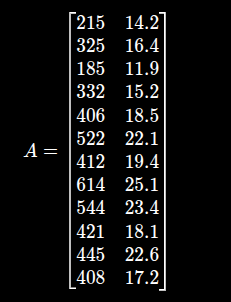


 - Rows = observations (days)
 - Columns = variables (sales and temperature)

### Accessing a Column

Get all temperatures:

In [4]:
print(store1['Temperature_°C'])

0     14.2
1     16.4
2     11.9
3     15.2
4     18.5
5     22.1
6     19.4
7     25.1
8     23.4
9     18.1
10    22.6
11    17.2
Name: Temperature_°C, dtype: float64


### Accessing a Row

Get data from Day 8:

In [5]:
print(store1.loc[8])

Days               8°_day
Ice_Cream_Sales       544
Temperature_°C       23.4
Name: 8, dtype: object


### Basic Statistics

Average sales:

In [6]:
print(store1['Ice_Cream_Sales'].mean())

402.4166666666667


Average temperature:

In [7]:
print(store1['Temperature_°C'].mean())

18.675


Maximum Sales Day

In [8]:
print(
    store1.loc[
        store1['Ice_Cream_Sales'].idxmax()
    ]
)

Days               7°_day
Ice_Cream_Sales       614
Temperature_°C       25.1
Name: 7, dtype: object


Notice that the hottest day also had the highest sales.

### Correlation

A very common matrix operation in Data Science:

In [9]:
print(store1.corr(numeric_only=True))

                 Ice_Cream_Sales  Temperature_°C
Ice_Cream_Sales         1.000000        0.957507
Temperature_°C          0.957507        1.000000


A correlation of about 0.96 indicates a strong positive relationship:

As temperature increases, ice cream sales tend to increase.

### Matrix Addition

Suppose another ice cream shop (store2) records:


In [10]:
import pandas as pd

store2_data = {
    'Ice_Cream_Sales': [120,180,100,150,200,250,210,300,280,220,240,210],
    'Temperature_°C': [13.0,15.0,11.0,14.0,17.0,20.0,18.0,24.0,22.0,17.0,21.0,16.0]
}

index = [
    '0°_day', '1°_day','2°_day','3°_day','4°_day',
    '5°_day','6°_day','7°_day','8°_day',
    '9°_day','10°_day','11°_day'
]

columns = ['Ice_Cream_Sales', 'Temperature_°C']

store2 = pd.DataFrame(
    store2_data,
    index=index,
    columns=columns
)

store2 = store2.rename_axis('Days').reset_index()

print(store2)

       Days  Ice_Cream_Sales  Temperature_°C
0    0°_day              120            13.0
1    1°_day              180            15.0
2    2°_day              100            11.0
3    3°_day              150            14.0
4    4°_day              200            17.0
5    5°_day              250            20.0
6    6°_day              210            18.0
7    7°_day              300            24.0
8    8°_day              280            22.0
9    9°_day              220            17.0
10  10°_day              240            21.0
11  11°_day              210            16.0


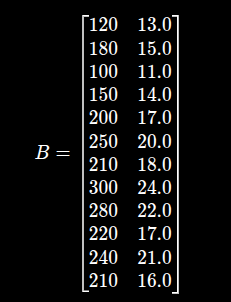

Adding matrices means adding corresponding elements:

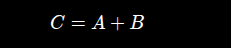

If you want C = A + B but only for Ice Cream Sales, keeping the original temperature column from Store 1 and not showing any temperature sum, you can do:

In [11]:
C = pd.DataFrame({
    'Days': store1['Days'],
    'Ice_Cream_Sales': (
        store1['Ice_Cream_Sales'] +
        store2['Ice_Cream_Sales']
    )
})

print(C)

       Days  Ice_Cream_Sales
0    0°_day              335
1    1°_day              505
2    2°_day              285
3    3°_day              482
4    4°_day              606
5    5°_day              772
6    6°_day              622
7    7°_day              914
8    8°_day              824
9    9°_day              641
10  10°_day              685
11  11°_day              618


You created a new DataFrame C by combining data from two existing DataFrames (store1 and store2).

##### Why is this useful?

Imagine:
```
store1 = Store A sales
store2 = Store B sales
```
Then C becomes:
```
Total company sales per day
```
which can be used later for:
```
plotting graphs
calculating averages
regression analysis
forecasting sales
```
This is one of the most common Pandas operations: creating a new DataFrame from calculations involving columns of other DataFrames.

Mathematically:

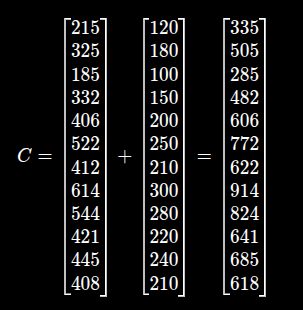

This is often easier to explain in a tutorial because the temperatures are identical measurements (or are not part of the quantity being combined), so only the sales column is added.

### Matrix Multiplication

This is the most important operation in AI and Data Science.

Suppose:

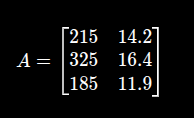

and we want to compute a score using:

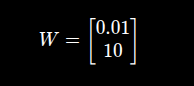

Here:

- Sales weight = 0.01
- Temperature weight = 10

Then

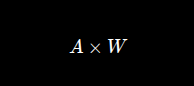

gives

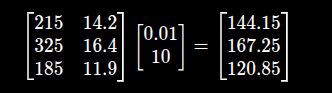

Let's verify the first row:

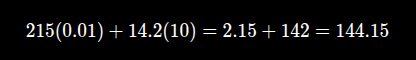

In [12]:
import numpy as np

A = np.array([
    [215,14.2],
    [325,16.4],
    [185,11.9]
])

W = np.array([
    [0.01],
    [10]
])

print(A @ W)

[[144.15]
 [167.25]
 [120.85]]


### Why Matrix Multiplication Matters

In Machine Learning, a prediction is often:

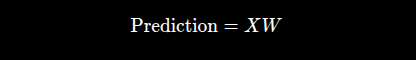

where:

- X = feature matrix (Temperature, Sales, Age, Income, etc.)
- W = learned weights
- Prediction = model output

a model might learn:

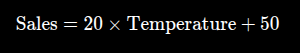

and matrix multiplication is what computes thousands or millions of those predictions efficiently.

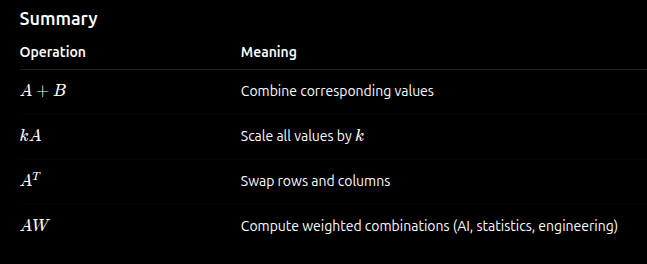

The last one, matrix multiplication, is the foundation of neural networks, regression, computer graphics, robotics, and scientific computing.



### Converting the DataFrame to a Matrix

In [13]:
matrix = store1[
    ['Ice_Cream_Sales', 'Temperature_°C']
].values

print(matrix)

[[215.   14.2]
 [325.   16.4]
 [185.   11.9]
 [332.   15.2]
 [406.   18.5]
 [522.   22.1]
 [412.   19.4]
 [614.   25.1]
 [544.   23.4]
 [421.   18.1]
 [445.   22.6]
 [408.   17.2]]


Now you have the numerical matrix used by many Machine Learning algorithms.

### Why This Example Is Important

This DataFrame is essentially a small Machine Learning dataset:

| Feature (X) | Target (Y)      |
|-------------|-----------------|
| Temperature | Ice Cream Sales |

A data scientist could use this matrix to:

- Predict future sales
- Estimate demand
- Optimize inventory
- Train a regression model
- Visualize trends

This is exactly how matrices appear in real-world AI and data science projects: rows are observations, columns are features, and the numbers represent measurable quantities.

Thanks for reading!